In [21]:
from utils.plot_utils_v2 import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytensor.tensor as pt
from pytensor.graph.op import Op
from scipy.integrate import solve_ivp
import pymc as pm
import json
import os

XLSX_PATH = 'data/mesocosm/AQUACOSM_VIMS-Ehux_CoreData-2.xlsx'

BAG_IDS = [1, 2, 3, 4, 5, 6, 7, 8]
BAG_TREATMENT = {1: 'Light', 2: 'Light', 3: 'Light', 4: 'Light',
                  5: 'Dark', 6: 'Dark', 7: 'Dark',
                  8: 'Control'}
BAG_COLUMN_OVERRIDE = {8: 'Fjord'}   # bag 8 -- adjust if the xlsx column is actually 'Bag 8'
BAG_CILIATE_FILE = {b: f'data/mesocosm/ciliates/Dataset {b}.csv' for b in BAG_IDS}  # verify per-bag filenames

FIT_SIGMA = False                      # False -> fixed sigma (recommended); True -> template's free HalfNormal
SIGMA_FIXED = 0.3 * np.log(10)         # ~0.6908, natural-log equiv. of old log10-scale sigma=0.3

DRAWS, TUNE, CHAINS, CORES = 10000, 8000, 4, 4   # trim vs. template's 30k/15k if 8 bags is slow; bump up later


In [22]:
## Cell 1 -- per-bag data loader ##

def load_bag_data(bag_id):
    col = BAG_COLUMN_OVERRIDE.get(bag_id, f'Bag {bag_id}')
    df = pd.read_excel(XLSX_PATH, usecols=['Taxonomic Group', 'Day', col])
    df = df.rename(columns={col: 'Abundance'})

    ciliate = pd.read_csv(BAG_CILIATE_FILE[bag_id], header=None, names=['Day', 'Abundance'])
    ciliate['Taxonomic Group'] = 'Ciliates'
    ciliate['Abundance'] = ciliate['Abundance'] / 1000

    result = pd.concat([df, ciliate])
    result['Taxonomic Group'] = result['Taxonomic Group'].replace({'Neuks_HighSS': 'G. huxleyi'})
    result = result.loc[result['Taxonomic Group'].isin(['G. huxleyi', 'Bacteria', 'EhV', 'Ciliates'])]

    ghux     = result.loc[result['Taxonomic Group'] == 'G. huxleyi']
    bacteria = result.loc[result['Taxonomic Group'] == 'Bacteria']
    ehv      = result.loc[result['Taxonomic Group'] == 'EhV']

    return {
        'ehux_live_time':     ghux['Day'].values.astype(float),
        'ehux_live_density':  ghux['Abundance'].values.astype(float),
        'bacteria_time':      bacteria['Day'].values.astype(float),
        'bacteria_density':   bacteria['Abundance'].values.astype(float),
        'ehv_time':           ehv['Day'].values.astype(float),
        'ehv_density':        ehv['Abundance'].values.astype(float),
        'ciliate_time':       ciliate['Day'].values.astype(float),
        'ciliate_density':    ciliate['Abundance'].values.astype(float),
    }

New equations:
dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B - phi_V * P * V - Gmax * P / (k_m + P) * Z
dDdt = delta_P * P + phi_B * P * B - lambda_D * D
dIdt = phi_V * P * V - lambda_I * I
dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
dVdt = beta_V * lambda_I * I
dZdt = theta_Z * Gmax * P / (k_m + P) * Z

phi_B = rho * (D+I)

In [23]:
## Cell 2 -- ODE systems ##
# Fitting model: 5 states (P, D, B, V, Z) -- lumped D drives phi_B, matches
# the Op's likelihood streams exactly. Used only inside SolveIVPWrapper.

def general_case(t, y, params):
    P, D, B, V, Z = np.maximum(y, 0.0)
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, \
        beta_V, phi_V, Gmax, k_m, theta_Z = params

    phi_B = rho * D
    graz  = Gmax * P / (k_m + P) * Z

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B - phi_V * P * V - graz
    dDdt = delta_P * P + phi_B * P * B + phi_V * P * V - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    dVdt = beta_V * phi_V * P * V
    dZdt = theta_Z * graz

    return [dPdt, dDdt, dBdt, dVdt, dZdt]


# Death-fractionation model: 9 states -- same core dynamics as above, PLUS
# four bookkeeping accumulators (D_nat/D_bact/D_vir/D_zoop) that track WHICH
# pathway killed each cell. No feedback into P/D/B/V/Z -- purely for
# post-fit death-signature analysis, run once per bag using that bag's
# posterior-median params (mirrors ecosystem_experiment.py exactly).

def general_case_death_track(t, y, params):
    P, D, B, V, Z, D_nat, D_bact, D_vir, D_zoop = np.maximum(y, 0.0)
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, \
        beta_V, phi_V, Gmax, k_m, theta_Z = params

    phi_B = rho * D
    graz  = Gmax * P / (k_m + P) * Z

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B - phi_V * P * V - graz
    dDdt = delta_P * P + phi_B * P * B + phi_V * P * V - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    dVdt = beta_V * phi_V * P * V
    dZdt = theta_Z * graz

    dD_nat  = delta_P * P    - lambda_D * D_nat
    dD_bact = phi_B * P * B  - lambda_D * D_bact
    dD_vir  = phi_V * P * V  - lambda_D * D_vir
    dD_zoop = graz           - lambda_D * D_zoop   # full grazing loss, not theta_Z-scaled

    return [dPdt, dDdt, dBdt, dVdt, dZdt, dD_nat, dD_bact, dD_vir, dD_zoop]


In [24]:
# Cell 3 -- Robust PyTensor Op (LSODA -> BDF fallback, penalize on failure) ##

class SolveIVPWrapper(Op):
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, t_grid, t_obs_list):
        self.t_grid = np.asarray(t_grid)
        self.t_obs_list = [np.asarray(t) for t in t_obs_list]
        self.lens = [len(t) for t in self.t_obs_list]

    def perform(self, node, inputs, outputs):
        theta_y0, = inputs
        theta = theta_y0[:13]
        y0 = theta_y0[13:]

        sol = None
        for method in ("LSODA", "BDF"):
            try:
                s = solve_ivp(fun=lambda t, y: general_case(t, y, theta),
                               t_span=(self.t_grid[0], self.t_grid[-1]),
                               y0=y0, t_eval=self.t_grid, method=method,
                               rtol=1e-6, atol=1e-9)
                if s.success and np.all(np.isfinite(s.y)):
                    sol = s
                    break
            except Exception:
                continue

        if sol is None:
            outputs[0][0] = np.full(sum(self.lens), 1e12)
            return

        states = np.maximum(sol.y, 1.0)
        preds = []
        for state_idx, t_obs in zip([0, 2, 3, 4], self.t_obs_list):  # P, B, V, Z columns
            preds.append(np.interp(t_obs, self.t_grid, states[state_idx]))
        outputs[0][0] = np.concatenate(preds)


In [25]:
## Cell 4 -- priors (same centers/sigmas as the pasted template) ##

def lognorm(name, centre, sigma=0.4):
    return pm.LogNormal(name, mu=np.log(centre), sigma=sigma)

KINETIC_NAMES = ['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D',
                  'beta_V', 'phi_V', 'Gmax', 'k_m', 'theta_Z']
IC_NAMES = ['P0', 'D0', 'B0', 'V0', 'Z0']

def build_and_fit_bag(bag_id, data, sample_kwargs):
    ehux_live_time,    ehux_live_density    = data['ehux_live_time'],    data['ehux_live_density']
    bacteria_time,     bacteria_density     = data['bacteria_time'],     data['bacteria_density']
    ehv_time,          ehv_density          = data['ehv_time'],          data['ehv_density']
    ciliate_time,      ciliate_density      = data['ciliate_time'],      data['ciliate_density']

    log_ehux_live_density = np.log(ehux_live_density + 1e-9)
    log_bacteria_density  = np.log(bacteria_density + 1e-9)
    log_ehv_density       = np.log(ehv_density + 1e-9)
    log_ciliate_density   = np.log(ciliate_density + 1e-9)

    all_times = np.union1d(np.union1d(ehux_live_time, bacteria_time),
                            np.union1d(ehv_time, ciliate_time))
    all_times = np.sort(np.unique(all_times))

    ode_op = SolveIVPWrapper(all_times, [ehux_live_time, bacteria_time, ehv_time, ciliate_time])
    n1, n2, n3, n4 = len(ehux_live_time), len(bacteria_time), len(ehv_time), len(ciliate_time)

    with pm.Model() as model:
        mu_P     = lognorm('mu_P',     5.888e-1, 0.4)
        k_P      = lognorm('k_P',      7.762e+6, 0.4)
        delta_P  = lognorm('delta_P',  5.012e-2, 0.4)
        mu_B     = lognorm('mu_B',     5.012e-1, 0.4)
        k_B      = lognorm('k_B',      1.096e+7, 0.4)
        beta_B   = lognorm('beta_B',   2.512e+1, 0.4)
        rho      = lognorm('rho',      7.413e-14, 0.4)
        lambda_D = lognorm('lambda_D', 3.020e-1, 0.4)
        beta_V   = lognorm('beta_V',   1.778e+2, 0.4)
        phi_V    = lognorm('phi_V',    1.175e-8, 0.4)
        Gmax     = lognorm('Gmax',     6.918e-1, 0.4)
        k_m      = lognorm('k_m',      1.175e+1, 0.4)
        theta_Z  = lognorm('theta_Z',  1.514e-1, 0.4)

        P0       = lognorm('P0', 1.000e+2, 0.3)
        D0_ratio = lognorm('D0_ratio', 1.000e+0, 0.2)
        D0       = pm.Deterministic('D0', P0 * D0_ratio)
        B0       = lognorm('B0', 3e+6, 0.3)
        # B0 = pm.Uniform('B0', lower=1e5, upper=1e7)
        V0       = lognorm('V0', 1e+5, 0.3)
        Z0       = lognorm('Z0', 2.630e+1, 0.3)

        if FIT_SIGMA:
            sigma_live     = pm.HalfNormal('sigma_live', 1)
            sigma_bacteria = pm.HalfNormal('sigma_bacteria', 1)
            sigma_virus    = pm.HalfNormal('sigma_virus', 1)
            sigma_ciliate  = pm.HalfNormal('sigma_ciliate', 1)
        else:
            sigma_live = sigma_bacteria = sigma_virus = sigma_ciliate = SIGMA_FIXED

        preds = ode_op(pt.stack([mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D,
                                  beta_V, phi_V, Gmax, k_m, theta_Z,
                                  P0, D0, B0, V0, Z0]))

        live          = preds[:n1]
        bacteria_pred = preds[n1:n1+n2]
        virus         = preds[n1+n2:n1+n2+n3]
        ciliate_pred  = preds[n1+n2+n3:]

        pm.Normal("Y_live",     mu=pm.math.log(live),          sigma=sigma_live,     observed=log_ehux_live_density)
        pm.Normal("Y_bacteria", mu=pm.math.log(bacteria_pred), sigma=sigma_bacteria, observed=log_bacteria_density)
        pm.Normal("Y_virus",    mu=pm.math.log(virus),         sigma=sigma_virus,    observed=log_ehv_density)
        pm.Normal("Y_ciliate",  mu=pm.math.log(ciliate_pred),  sigma=sigma_ciliate,  observed=log_ciliate_density)

        trace = pm.sample(step=pm.DEMetropolisZ(), return_inferencedata=True, **sample_kwargs)

    return model, trace

In [26]:
## Cell 5 -- death-fractionation from best-fit (posterior-median) params ##

def death_fractionation(median_params, t_max, n_grid=300):
    theta = [median_params[n] for n in KINETIC_NAMES]
    y0_5state = [median_params['P0'], median_params['D0'], median_params['B0'],
                 median_params['V0'], median_params['Z0']]
    # D_nat/D_bact/D_vir/D_zoop start at 0 except D_nat, which absorbs the
    # initial lumped D0 (no historical attribution available at t=0 --
    # same convention used in ecosystem_experiment.py)
    y0_9state = y0_5state + [median_params['D0'], 0.0, 0.0, 0.0]

    t_eval = np.linspace(0, t_max, n_grid)
    sol = None
    for method in ("LSODA", "BDF"):
        try:
            s = solve_ivp(fun=lambda t, y: general_case_death_track(t, y, theta),
                           t_span=(0, t_max), y0=y0_9state, t_eval=t_eval,
                           method=method, rtol=1e-6, atol=1e-9)
            if s.success and np.all(np.isfinite(s.y)):
                sol = s
                break
        except Exception:
            continue
    if sol is None:
        return None

    P, D, B, V, Z, D_nat, D_bact, D_vir, D_zoop = np.maximum(sol.y, 0.0)

    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, \
        beta_V, phi_V, Gmax, k_m, theta_Z = theta
    phi_B = rho * D
    graz  = Gmax * P / (k_m + P) * Z

    flux_nat  = delta_P * P
    flux_bact = phi_B * P * B
    flux_vir  = phi_V * P * V
    flux_zoop = graz
    total_sum = flux_nat.sum() + flux_bact.sum() + flux_vir.sum() + flux_zoop.sum() + 1e-30

    fractions = {
        'Natural':   float(flux_nat.sum() / total_sum),
        'Bacterial': float(flux_bact.sum() / total_sum),
        'Viral':     float(flux_vir.sum() / total_sum),
        'Grazing':   float(flux_zoop.sum() / total_sum),
    }
    curves = {'t': t_eval, 'D_nat': D_nat, 'D_bact': D_bact, 'D_vir': D_vir, 'D_zoop': D_zoop,
              'P': P, 'B': B, 'V': V, 'Z': Z}
    return fractions, curves

In [27]:
## Cell 6 -- run the loop over all 8 bags ##

bag_results = {}   # bag_id -> {'median_params':..., 'fractions':..., 'curves':...}

for bag_id in BAG_IDS:
    print(f'\n=== Fitting Bag {bag_id} ({BAG_TREATMENT[bag_id]}) ===')
    data = load_bag_data(bag_id)

    model, trace = build_and_fit_bag(
        bag_id, data,
        sample_kwargs=dict(draws=DRAWS, tune=TUNE, chains=CHAINS, cores=CORES),
    )

    post = trace.posterior.stack(draws=("chain", "draw"))
    median_params = {n: float(np.median(post[n].values)) for n in KINETIC_NAMES + IC_NAMES}

    t_max = max(data['ehux_live_time'].max(), data['bacteria_time'].max(),
                data['ehv_time'].max(), data['ciliate_time'].max())
    fractions, curves = death_fractionation(median_params, t_max)

    bag_results[bag_id] = {
        'treatment': BAG_TREATMENT[bag_id],
        'data': data,
        'median_params': median_params,
        'fractions': fractions,
        'curves': curves,
        'trace': trace,
    }

    print(f'  Median params: {median_params}')
    print(f'  Death fractions: {fractions}')


=== Fitting Bag 1 (Light) ===


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, beta_V, phi_V, Gmax, k_m, theta_Z, P0, D0_ratio, B0, V0, Z0]


Output()

Sampling 4 chains for 8_000 tune and 10_000 draw iterations (32_000 + 40_000 draws total) took 56 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  Median params: {'mu_P': 0.42778498636177187, 'k_P': 7033249.273736194, 'delta_P': 0.05439922778754527, 'mu_B': 0.4210891864315278, 'k_B': 4724287.363923075, 'beta_B': 31.176333634736444, 'rho': 6.746486988566384e-14, 'lambda_D': 0.28820927584879147, 'beta_V': 237.7930054904169, 'phi_V': 5.875708951260175e-08, 'Gmax': 0.47721613868853635, 'k_m': 12.881873079904953, 'theta_Z': 0.15345139901786153, 'P0': 105.00020712761845, 'D0': 106.23257391037974, 'B0': 3142257.5417487714, 'V0': 415655.3927826065, 'Z0': 27.048864516488692}
  Death fractions: {'Natural': 0.1348905603566431, 'Bacterial': 0.015024807147257081, 'Viral': 0.8430812395464929, 'Grazing': 0.007003392949606785}

=== Fitting Bag 2 (Light) ===


...

  Median params: {'mu_P': 0.42490598584189576, 'k_P': 7335116.454864967, 'delta_P': 0.10541535681933255, 'mu_B': 0.30402794936380767, 'k_B': 7076713.787475069, 'beta_B': 32.92410086636203, 'rho': 1.0805495116218415e-13, 'lambda_D': 0.24022040730996772, 'beta_V': 688.3173391410509, 'phi_V': 5.8973969670999314e-08, 'Gmax': 0.3538925696112109, 'k_m': 14.214286737257876, 'theta_Z': 0.16546908096591825, 'P0': 111.95919147823932, 'D0': 136.90257971075005, 'B0': 3384801.8814315894, 'V0': 430588.1749537734, 'Z0': 18.494683076517017}
  Death fractions: {'Natural': 0.2528247982953378, 'Bacterial': 0.012488015585944298, 'Viral': 0.7262698770804995, 'Grazing': 0.008417309038218473}

=== Fitting Bag 8 (Control) ===


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, beta_V, phi_V, Gmax, k_m, theta_Z, P0, D0_ratio, B0, V0, Z0]


Output()

Sampling 4 chains for 8_000 tune and 10_000 draw iterations (32_000 + 40_000 draws total) took 55 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  Median params: {'mu_P': 0.33146876461503305, 'k_P': 9296660.581186123, 'delta_P': 0.05234809947253537, 'mu_B': 0.5950214741003038, 'k_B': 2162802.092321348, 'beta_B': 14.35428682437894, 'rho': 1.186809641193075e-13, 'lambda_D': 0.2133373881833033, 'beta_V': 601.163396140232, 'phi_V': 1.0311952386597905e-08, 'Gmax': 0.53162110541893, 'k_m': 17.66978963385837, 'theta_Z': 0.03943327042084192, 'P0': 53.12418688717948, 'D0': 43.572395134553304, 'B0': 2913279.4341472634, 'V0': 85973.33390436468, 'Z0': 17.23387612899673}
  Death fractions: {'Natural': 0.9093014540283259, 'Bacterial': 0.004613833380041907, 'Viral': 0.0192110526284274, 'Grazing': 0.06687365996320484}


In [28]:
## Cell 7 -- save best-fit parameters (per bag + combined) for reuse elsewhere ##

os.makedirs('data/bag_fits', exist_ok=True)
for bag_id, res in bag_results.items():
    with open(f'data/bag_fits/bag_{bag_id}_median_params.json', 'w') as f:
        json.dump(res['median_params'], f, indent=2)

all_params_table = pd.DataFrame({b: r['median_params'] for b, r in bag_results.items()}).T
all_params_table.index.name = 'bag_id'
all_params_table['treatment'] = [BAG_TREATMENT[b] for b in all_params_table.index]
all_params_table.to_csv('data/bag_fits/all_bags_median_params.csv')
print(all_params_table.round(4).to_string())

          mu_P           k_P  delta_P    mu_B           k_B   beta_B  rho  lambda_D    beta_V  phi_V    Gmax      k_m  theta_Z        P0        D0            B0           V0       Z0 treatment
bag_id                                                                                                                                                                                          
1       0.4278  7.033249e+06   0.0544  0.4211  4.724287e+06  31.1763  0.0    0.2882  237.7930    0.0  0.4772  12.8819   0.1535  105.0002  106.2326  3.142258e+06  415655.3928  27.0489     Light
2       0.4478  7.805929e+06   0.0639  0.6245  4.984666e+06  22.3264  0.0    0.2366  249.9974    0.0  0.5009  11.8742   0.1257  103.7479  107.2755  3.141195e+06  375647.5535  26.7790     Light
3       0.4461  7.702034e+06   0.0571  0.4574  5.272999e+06  21.4549  0.0    0.2658  224.5488    0.0  0.4950  13.2998   0.1825   99.7917  102.8560  2.566292e+06  479409.1958  23.4567     Light
4       0.6509  9.396503e+06   0.11

In [29]:
import seaborn as sns
import os

os.makedirs('figures/boxplots', exist_ok=True)

for i in range(len(all_params_table.columns) - 1):
    param = all_params_table.columns[i]

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.boxplot(data=all_params_table.loc[all_params_table['treatment']!='Control'], x='treatment', y=all_params_table[param], ax=ax)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))
    ax.set_ylabel(param)
    plt.tight_layout()
    # plt.savefig(f'figures/boxplots/{param}_boxplot.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

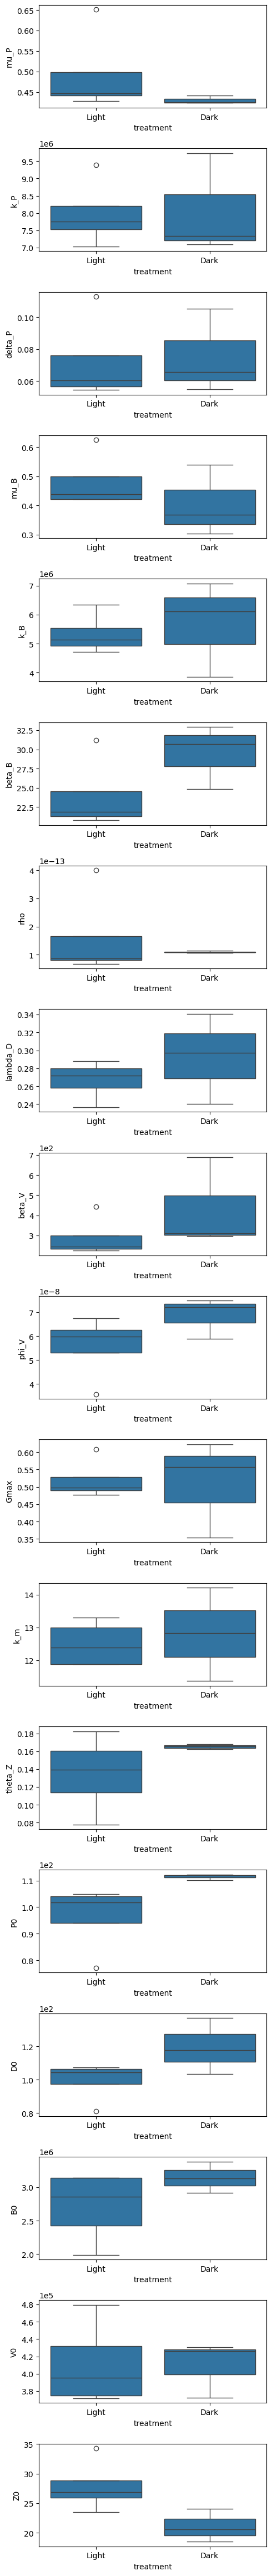

In [30]:
import seaborn as sns
f, ax = plt.subplots(figsize=(5,2.5*len(all_params_table.columns)-1), nrows=18)
for i in range(len(all_params_table.columns)-1):
    sns.boxplot(data=all_params_table.loc[all_params_table['treatment']!='Control'], x='treatment', y=all_params_table[all_params_table.columns[i]], ax = ax[i])
    ax[i].ticklabel_format(axis='y', style='sci', scilimits=(-2,2))
plt.tight_layout()

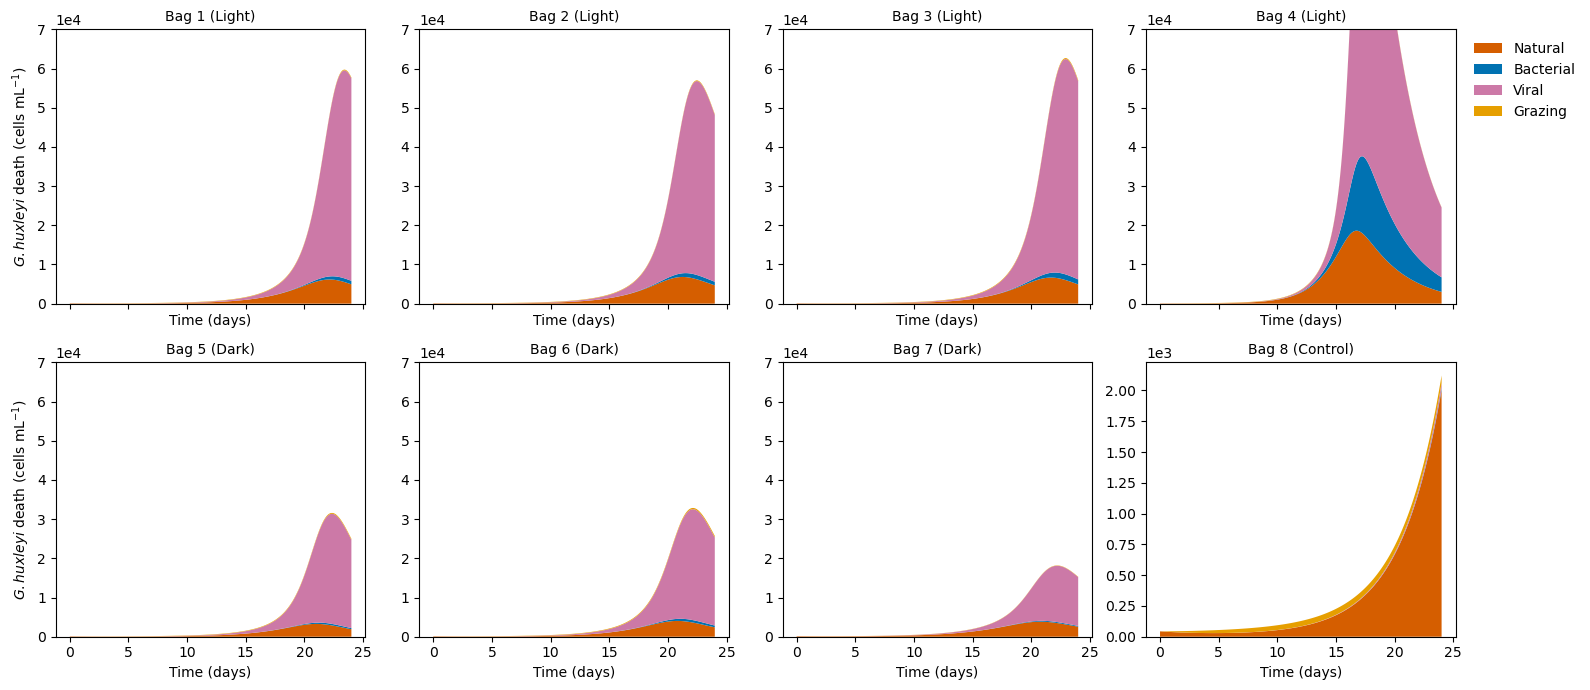

In [31]:
## Cell 8 -- per-bag death-signature plots (stackplot of D_nat/D_bact/D_vir/D_zoop) ##

colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']
TREATMENT_EDGE = {'Light': colors[3], 'Dark': colors[4], 'Control': colors[7]}

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for ax, bag_id in zip(axes.flat, BAG_IDS):
    c = bag_results[bag_id]['curves']
    ax.stackplot(c['t'], c['D_nat'], c['D_bact'], c['D_vir'], c['D_zoop'],
                 labels=['Natural', 'Bacterial', 'Viral', 'Grazing'],
                 colors=[colors[5], colors[4], colors[6], colors[0]])
    treat = bag_results[bag_id]['treatment']
    ax.set_title(f'Bag {bag_id} ({treat})', fontsize=10)
    ax.set_xlabel('Time (days)')
    ax.ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
axes[0, 0].set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)')
axes[1, 0].set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)')
axes[0, -1].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
axes[0, 0].set_ylim(0, 7e4)
axes[1, 0].set_ylim(0, 7e4)
axes[0, 1].set_ylim(0, 7e4)
axes[1, 1].set_ylim(0, 7e4)
axes[0, 2].set_ylim(0, 7e4)
axes[1, 2].set_ylim(0, 7e4)
axes[0, 3].set_ylim(0, 7e4)
plt.tight_layout()
# plt.savefig('figures/bag_death_signatures.png', dpi=300, bbox_inches='tight')
plt.show()


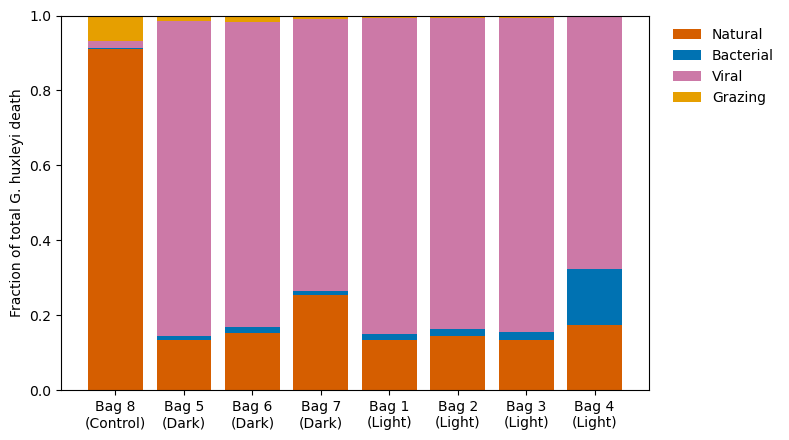


Death fractionation by treatment (mean across bags):
           Natural  Bacterial  Viral  Grazing
treatment                                    
Control      0.909      0.005  0.019    0.067
Dark         0.179      0.014  0.793    0.014
Light        0.147      0.051  0.796    0.006


In [32]:
## Cell 9 -- overall fractionation summary across all 8 bags ##

frac_df = pd.DataFrame({b: r['fractions'] for b, r in bag_results.items()}).T
frac_df.index.name = 'bag_id'
frac_df['treatment'] = [BAG_TREATMENT[b] for b in frac_df.index]
frac_df = frac_df.sort_values(['treatment', 'bag_id'])

fig, ax = plt.subplots(figsize=(8, 4.5))
bottom = np.zeros(len(frac_df))
pathway_colors = {'Natural': colors[5], 'Bacterial': colors[4], 'Viral': colors[6], 'Grazing': colors[0]}
x_labels = [f'Bag {b}\n({t})' for b, t in zip(frac_df.index, frac_df['treatment'])]

for pathway in ['Natural', 'Bacterial', 'Viral', 'Grazing']:
    ax.bar(x_labels, frac_df[pathway], bottom=bottom, label=pathway, color=pathway_colors[pathway])
    bottom += frac_df[pathway].values

ax.set_ylabel('Fraction of total G. huxleyi death')
ax.set_ylim(0, 1)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
# plt.savefig('figures/bag_death_fractionation_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nDeath fractionation by treatment (mean across bags):')
print(frac_df.groupby('treatment')[['Natural', 'Bacterial', 'Viral', 'Grazing']].mean().round(3).to_string())


In [33]:
bag_results[1]['trace']

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

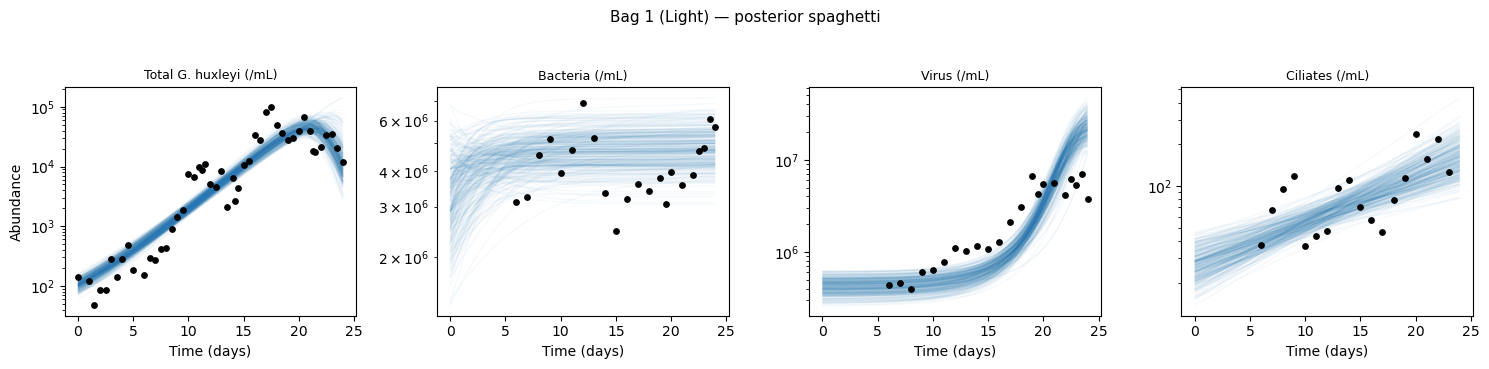

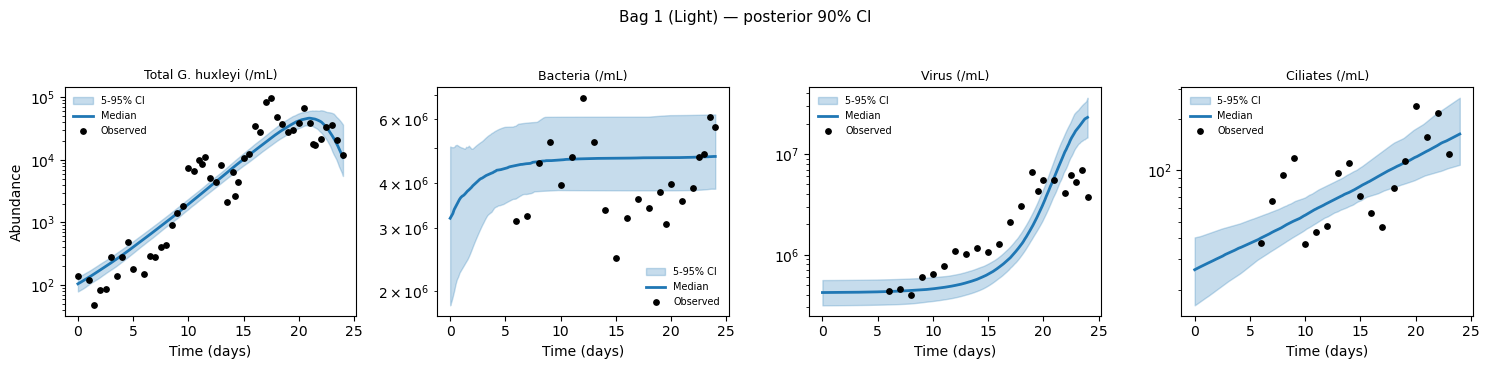

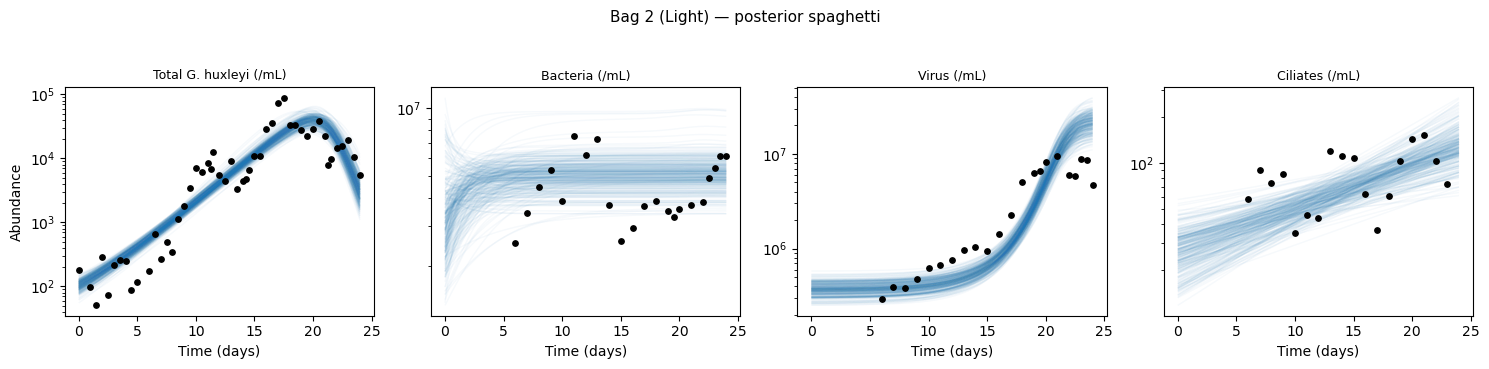

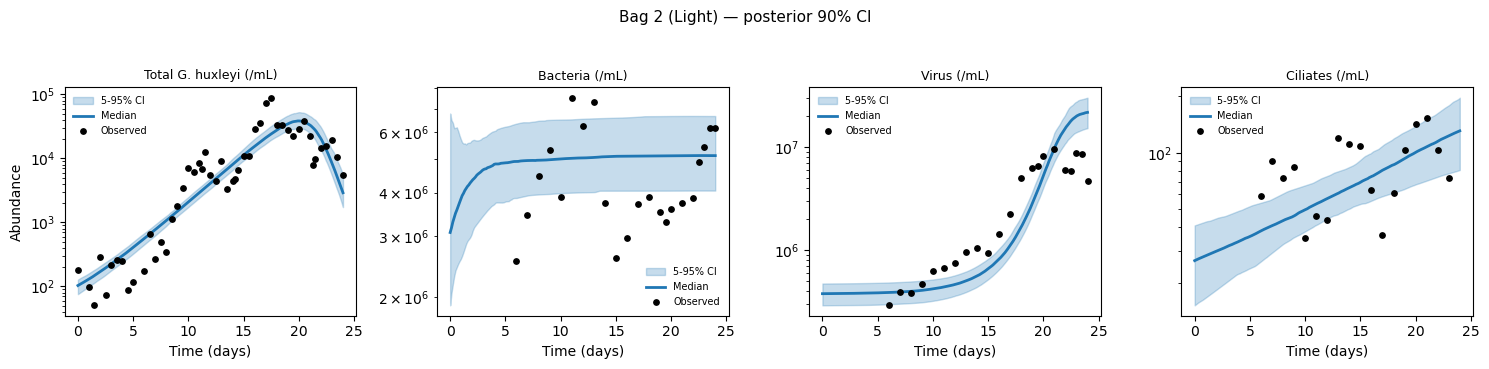

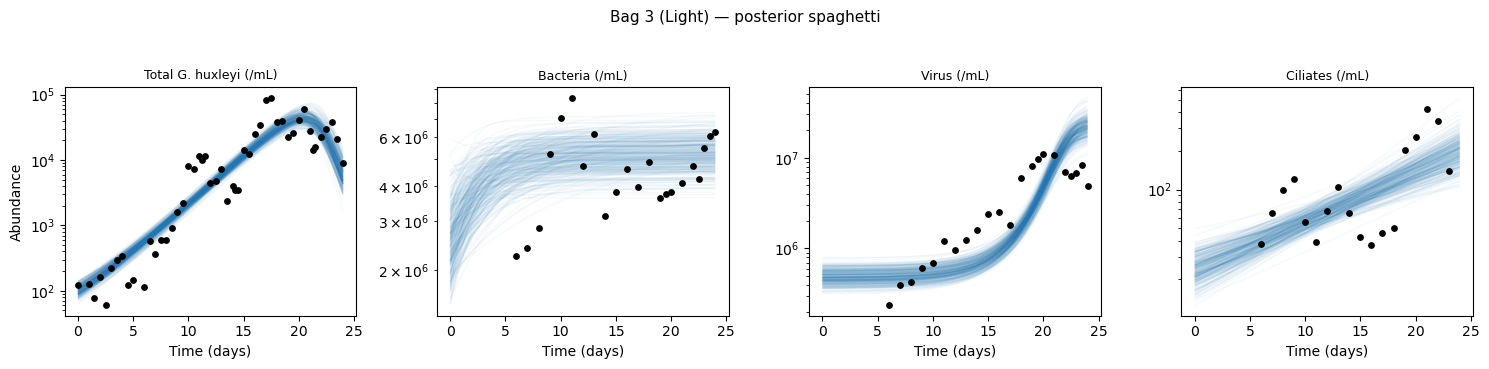

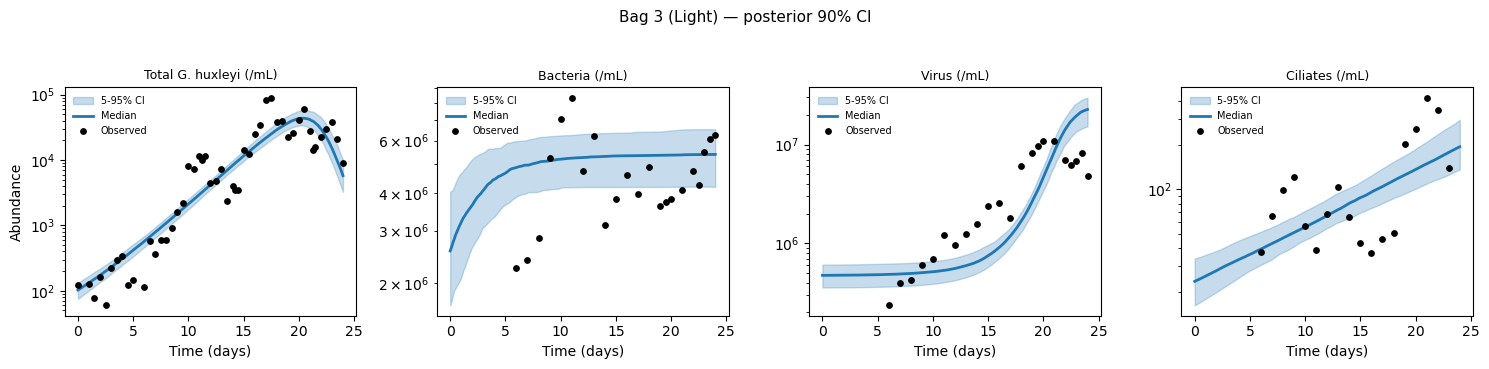

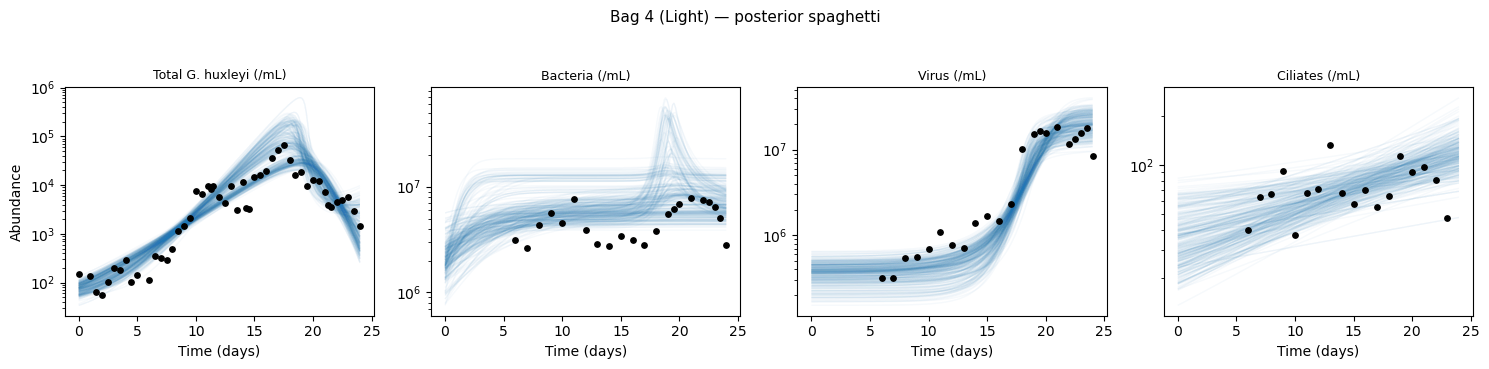

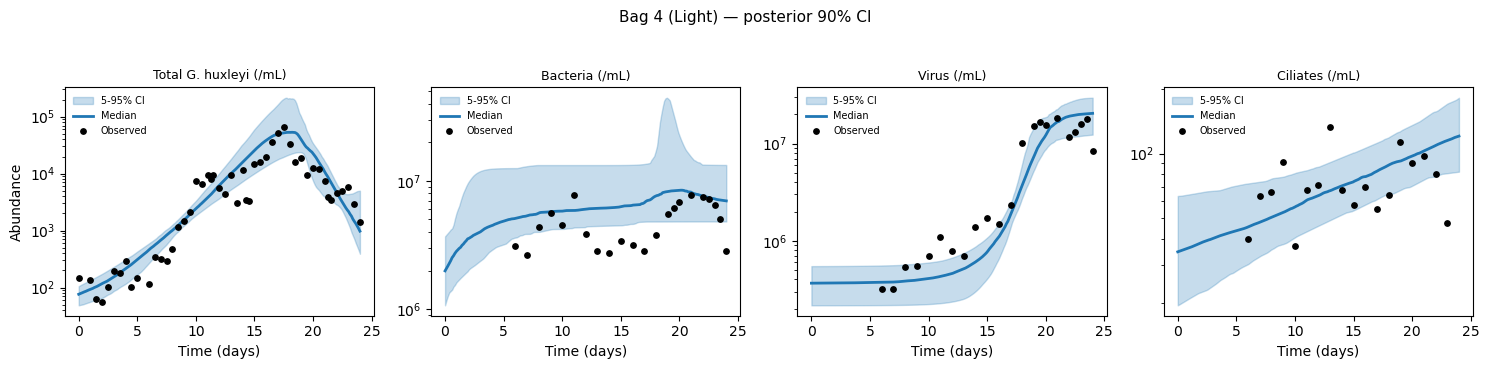

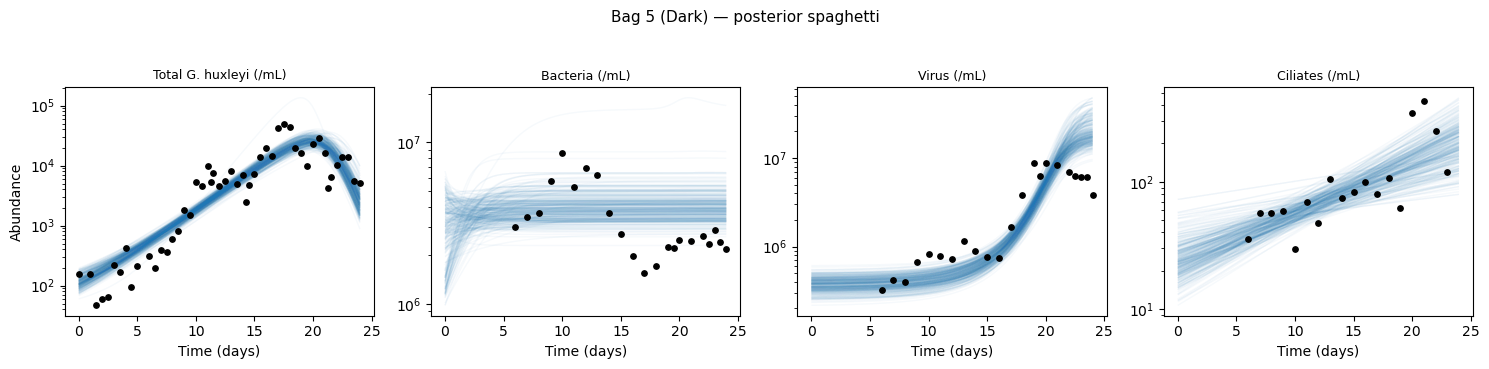

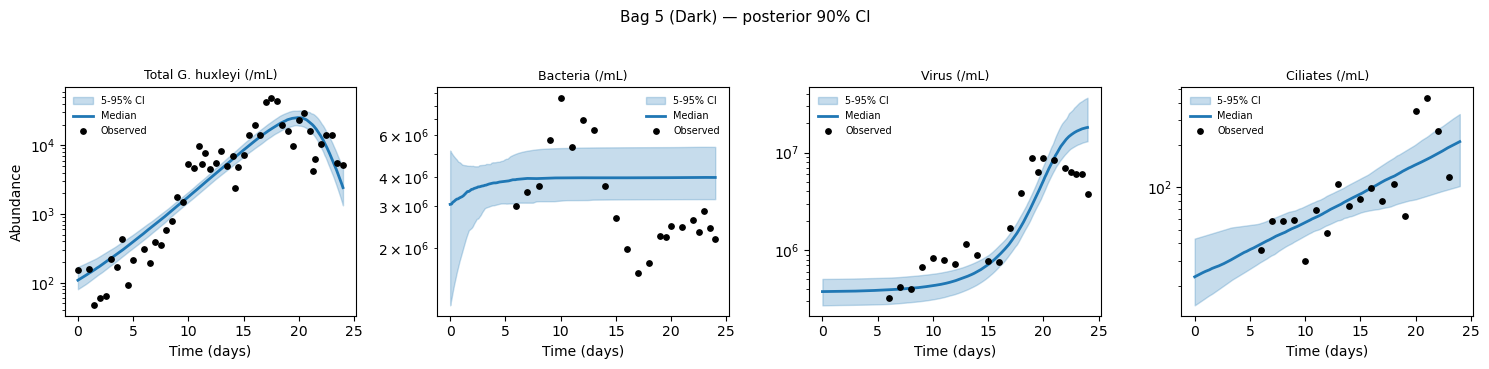

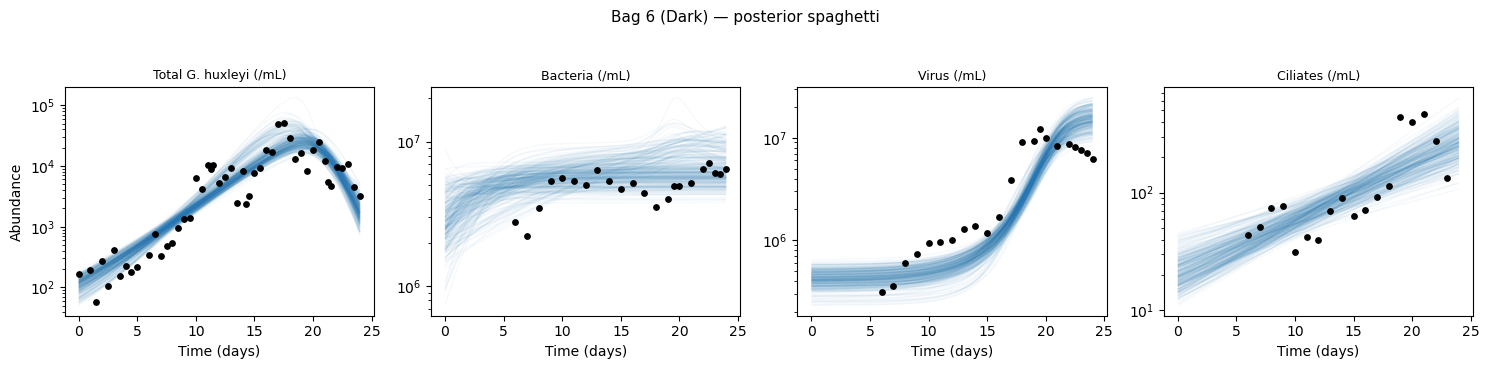

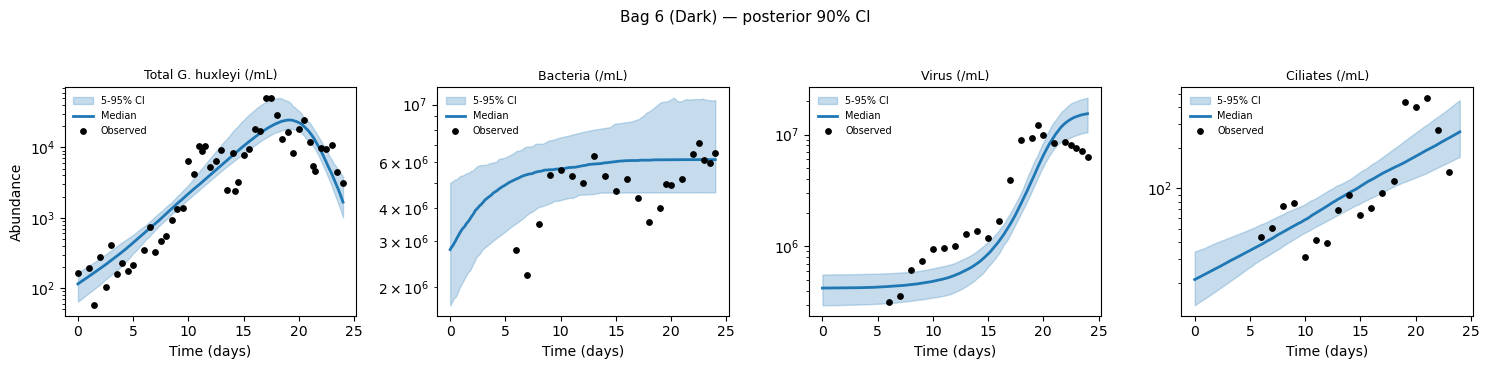

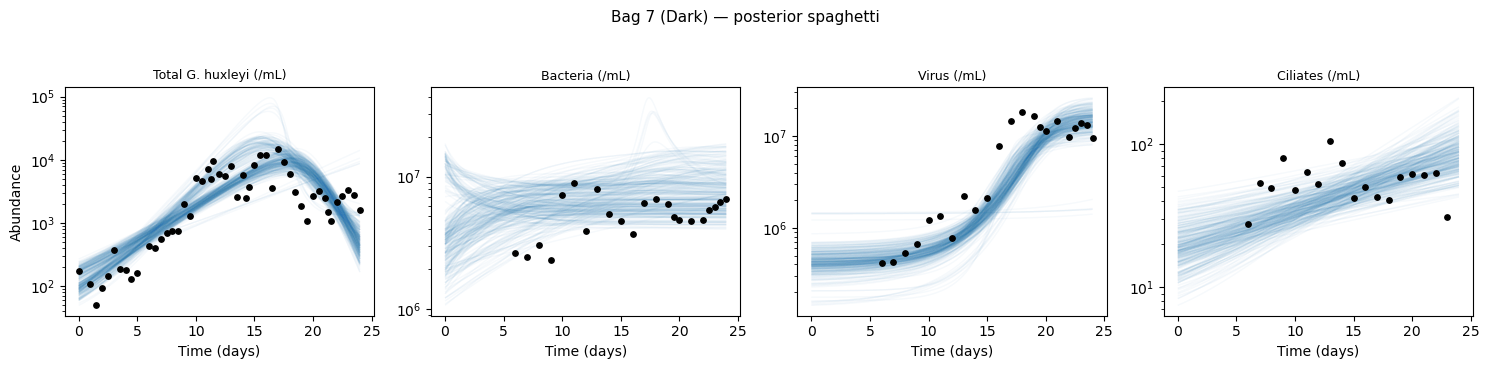

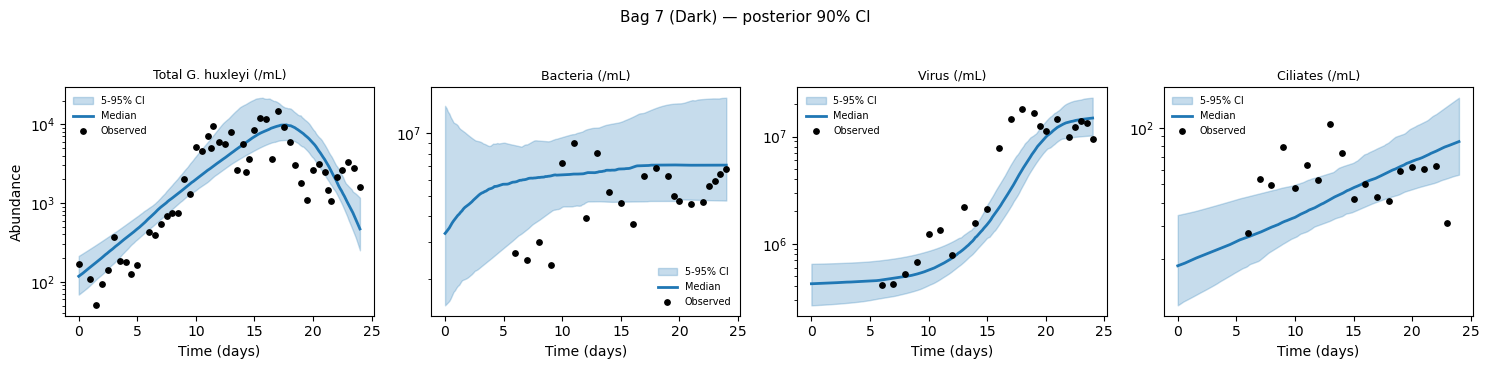

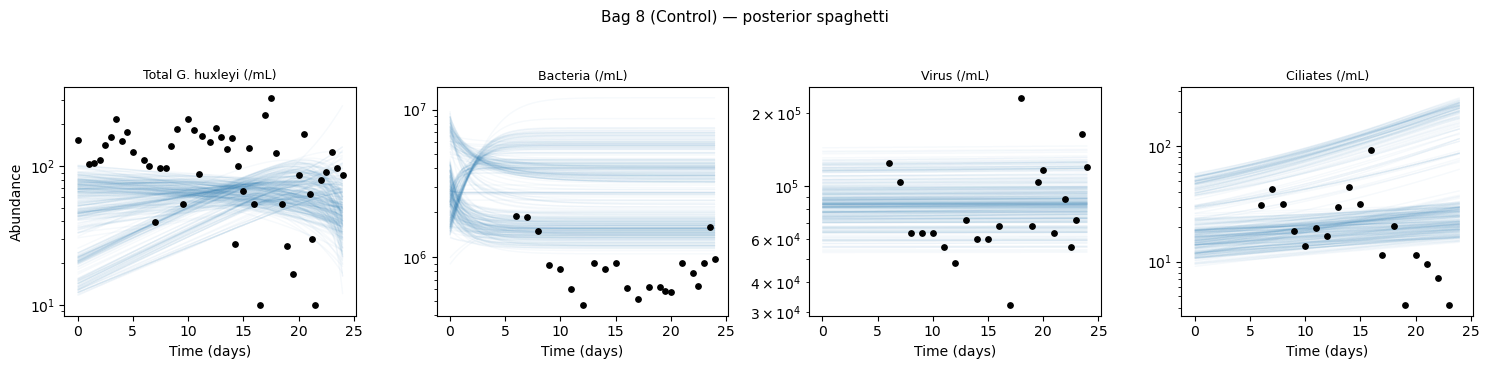

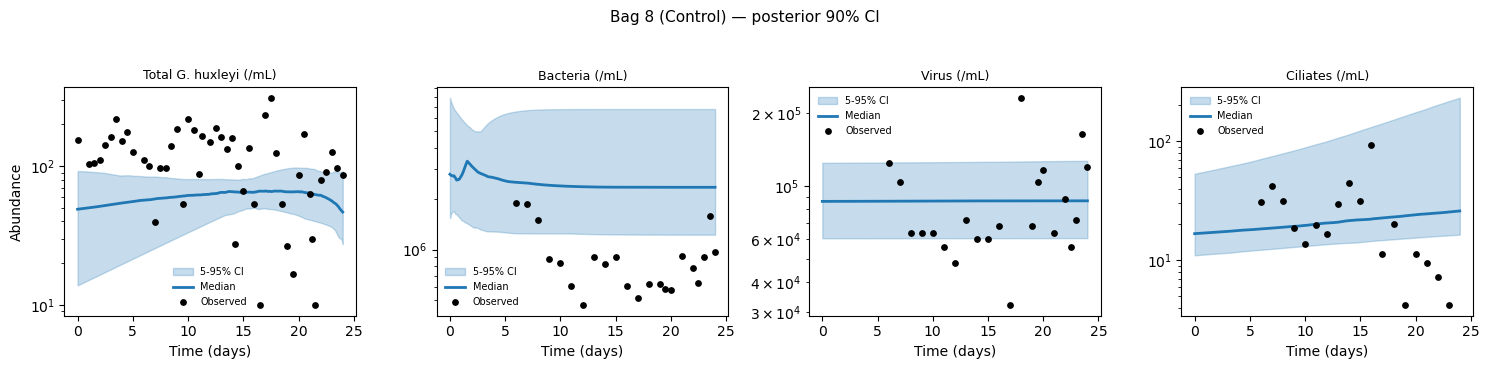

In [34]:
# %% [markdown]
# ## Save traces + per-bag posterior spaghetti/band plots
#
# Run this AFTER Cell 9 (the full sampling loop + fractionation summary)
# has completed and `bag_results` is populated in memory.
#
# Saves each bag's full trace to disk (Cell 6 only ever saved median_params,
# not the InferenceData itself -- so without this, a kernel restart means
# re-running all 8 fits from scratch), then generalizes MCMC_whole_env.py's
# eco_posterior_spaghetti/eco_posterior_bands (which hardcoded globals like
# ehux_live_time) to take a bag's `data` dict and `trace` explicitly, and
# loops over every bag.

# %%
## Cell 10 -- save every bag's full trace to disk ##

import arviz as az

# os.makedirs('data/bag_fits/traces', exist_ok=True)
# for bag_id, res in bag_results.items():
#     res['trace'].to_netcdf(f'data/bag_fits/traces/bag_{bag_id}_trace.nc')
#     print(f'Saved trace for Bag {bag_id} -> data/bag_fits/traces/bag_{bag_id}_trace.nc')

# To reload later without re-sampling:
#   trace = az.from_netcdf(f'data/bag_fits/traces/bag_{bag_id}_trace.nc')

# %%
## Cell 11 -- per-bag posterior spaghetti + confidence band plotting ##

from scipy.integrate import solve_ivp
from matplotlib.collections import LineCollection

STATE_COL = {'P': 0, 'D': 1, 'B': 2, 'V': 3, 'Z': 4}

def _posterior_1d(trace, name):
    post = trace.posterior.stack(draws=("chain", "draw"))
    return np.asarray(post[name].values).reshape(-1)

def _run_one_draw(theta, y0, t_eval, method_list=("LSODA", "BDF")):
    for method in method_list:
        try:
            sol = solve_ivp(fun=lambda t, y: general_case(t, y, theta),
                             t_span=(t_eval[0], t_eval[-1]), y0=y0, t_eval=t_eval,
                             method=method, rtol=1e-6, atol=1e-9)
            if sol.success and np.all(np.isfinite(sol.y)):
                return np.maximum(sol.y, 1.0)
        except Exception:
            continue
    return None

def _sample_draws(trace, n_samples, burn_in, seed):
    all_names = KINETIC_NAMES + IC_NAMES
    vals = {n: _posterior_1d(trace, n) for n in all_names}
    n_avail = len(vals['mu_P'])
    n_samples = min(n_samples, n_avail - burn_in)  # clamp instead of hard-asserting
    rng = np.random.default_rng(seed)
    idxs = rng.choice(np.arange(burn_in, n_avail), size=n_samples, replace=False)
    return vals, idxs

def _obs_panels(data):
    """Build the 4-stream panel spec from a single bag's data dict."""
    return [
        ('P', 'Total G. huxleyi (/mL)', data['ehux_live_time'], data['ehux_live_density']),
        ('B', 'Bacteria (/mL)',          data['bacteria_time'],  data['bacteria_density']),
        ('V', 'Virus (/mL)',             data['ehv_time'],       data['ehv_density']),
        ('Z', 'Ciliates (/mL)',          data['ciliate_time'],   data['ciliate_density']),
    ]

def eco_posterior_spaghetti_bag(trace, data, bag_id, n_samples=300, burn_in=0, seed=42,
                                 n_grid=200, alpha=0.04, save_path=None):
    obs_panels = _obs_panels(data)
    t_max = max(np.max(t) for _, _, t, _ in obs_panels)
    t_eval = np.linspace(0, t_max, n_grid)
    vals, idxs = _sample_draws(trace, n_samples, burn_in, seed)

    segments = {k: [] for k, *_ in obs_panels}
    for i in idxs:
        theta = [vals[n][i] for n in KINETIC_NAMES]
        y0    = [vals[n][i] for n in IC_NAMES]
        states = _run_one_draw(theta, y0, t_eval)
        if states is None:
            continue
        for key, *_ in obs_panels:
            segments[key].append(np.column_stack((t_eval, states[STATE_COL[key]]))[:, None, :])

    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharex=True)
    for ax, (key, label, t_obs, v_obs) in zip(axes, obs_panels):
        if segments[key]:
            arr = np.concatenate(segments[key], axis=1).transpose(1, 0, 2)
            ax.add_collection(LineCollection(arr, linewidths=1.0, alpha=alpha, color='C0'))
            ax.autoscale_view()
        ax.scatter(t_obs, v_obs, color='black', s=15, zorder=5)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Time (days)')
        ax.set_yscale('log')
    axes[0].set_ylabel('Abundance')
    treatment = BAG_TREATMENT.get(bag_id, '?')
    fig.suptitle(f'Bag {bag_id} ({treatment}) — posterior spaghetti', y=1.04, fontsize=11)
    plt.tight_layout()
    # if save_path:
    #     plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def eco_posterior_bands_bag(trace, data, bag_id, n_samples=200, burn_in=0, seed=42,
                             n_grid=200, lo=5, hi=95, save_path=None):
    obs_panels = _obs_panels(data)
    t_max = max(np.max(t) for _, _, t, _ in obs_panels)
    t_eval = np.linspace(0, t_max, n_grid)
    vals, idxs = _sample_draws(trace, n_samples, burn_in, seed)

    curves = {k: [] for k, *_ in obs_panels}
    for i in idxs:
        theta = [vals[n][i] for n in KINETIC_NAMES]
        y0    = [vals[n][i] for n in IC_NAMES]
        states = _run_one_draw(theta, y0, t_eval)
        if states is None:
            continue
        for key, *_ in obs_panels:
            curves[key].append(states[STATE_COL[key]])

    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharex=True)
    for ax, (key, label, t_obs, v_obs) in zip(axes, obs_panels):
        if curves[key]:
            arr = np.array(curves[key])
            p_lo, p_med, p_hi = np.percentile(arr, [lo, 50, hi], axis=0)
            ax.fill_between(t_eval, p_lo, p_hi, alpha=0.25, color='C0', label=f'{lo}-{hi}% CI')
            ax.plot(t_eval, p_med, color='C0', lw=2, label='Median')
        ax.scatter(t_obs, v_obs, color='black', s=15, zorder=5, label='Observed')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Time (days)')
        ax.set_yscale('log')
        ax.legend(fontsize=7, frameon=False)
    axes[0].set_ylabel('Abundance')
    treatment = BAG_TREATMENT.get(bag_id, '?')
    fig.suptitle(f'Bag {bag_id} ({treatment}) — posterior 90% CI', y=1.04, fontsize=11)
    plt.tight_layout()
    # if save_path:
    #     plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# %%
## Cell 12 -- loop over every bag, generate + save both plot types ##

os.makedirs('figures/bags', exist_ok=True)

for bag_id in BAG_IDS:
    res = bag_results[bag_id]
    data, trace = res['data'], res['trace']

    eco_posterior_spaghetti_bag(
        trace, data, bag_id, n_samples=300,
        # save_path=f'figures/bags/bag_{bag_id}_spaghetti.png',
    )
    eco_posterior_bands_bag(
        trace, data, bag_id, n_samples=200,
        # save_path=f'figures/bags/bag_{bag_id}_bands.png',
    )
